## Backtrader example 1
In this file we follow the following steps:
- Installing libraries
- Importing
- Fetching data, Cleaning data  
- Initialization and feeding data to  Backtrader's data format
- Running cerebro (the engine class of Backtrader)
- Plotting

### Installing libraries

In [79]:
# %pip install backtrader

# %pip install matplotlib

# %pip install ipympl

### Importing

In [98]:
import backtrader as bt
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
#%matplotlib widget
%matplotlib inline

### Fetching data, Cleaning data

In [99]:
# Parameters
pair = "EURUSD=X"
start_date = "2024-01-01"
end_date = "2024-02-28"
interval = "1h"

In [100]:
fxdata = yf.Ticker(pair)

In [101]:
fxdata = fxdata.history(start=start_date, end=end_date, interval=interval)
fxdata

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2024-01-01 18:00:00+00:00,1.105583,1.105583,1.105583,1.105583,0,0.0,0.0
2024-01-01 19:00:00+00:00,1.105583,1.105583,1.105339,1.105339,0,0.0,0.0
2024-01-01 20:00:00+00:00,1.105339,1.105339,1.103875,1.104240,0,0.0,0.0
2024-01-01 21:00:00+00:00,1.104240,1.105217,1.104240,1.105217,0,0.0,0.0
2024-01-01 22:00:00+00:00,1.104850,1.105094,1.104606,1.104728,0,0.0,0.0
...,...,...,...,...,...,...,...
2024-02-27 19:00:00+00:00,1.085305,1.085305,1.084363,1.084716,0,0.0,0.0
2024-02-27 20:00:00+00:00,1.084716,1.085069,1.084481,1.084716,0,0.0,0.0
2024-02-27 21:00:00+00:00,1.084716,1.084952,1.084716,1.084834,0,0.0,0.0


In [102]:
cols = ['Dividends','Stock Splits']   
(fxdata[cols] == 0).all()
fxdata.drop(columns= cols, inplace = True)
fxdata

,Open,High,Low,Close,Volume
Datetime,,,,,
2024-01-01 18:00:00+00:00,1.105583,1.105583,1.105583,1.105583,0
2024-01-01 19:00:00+00:00,1.105583,1.105583,1.105339,1.105339,0
2024-01-01 20:00:00+00:00,1.105339,1.105339,1.103875,1.104240,0
2024-01-01 21:00:00+00:00,1.104240,1.105217,1.104240,1.105217,0
2024-01-01 22:00:00+00:00,1.104850,1.105094,1.104606,1.104728,0
...,...,...,...,...,...
2024-02-27 19:00:00+00:00,1.085305,1.085305,1.084363,1.084716,0
2024-02-27 20:00:00+00:00,1.084716,1.085069,1.084481,1.084716,0
2024-02-27 21:00:00+00:00,1.084716,1.084952,1.084716,1.084834,0


In [103]:
value = fxdata.iloc[0, 0]
print(value) 

1.1055831909179688


In [104]:
fxdata = pd.DataFrame(fxdata)
fxdata.index = pd.to_datetime(fxdata.index)

In [105]:
fxdata

,Open,High,Low,Close,Volume
Datetime,,,,,
2024-01-01 18:00:00+00:00,1.105583,1.105583,1.105583,1.105583,0
2024-01-01 19:00:00+00:00,1.105583,1.105583,1.105339,1.105339,0
2024-01-01 20:00:00+00:00,1.105339,1.105339,1.103875,1.104240,0
2024-01-01 21:00:00+00:00,1.104240,1.105217,1.104240,1.105217,0
2024-01-01 22:00:00+00:00,1.104850,1.105094,1.104606,1.104728,0
...,...,...,...,...,...
2024-02-27 19:00:00+00:00,1.085305,1.085305,1.084363,1.084716,0
2024-02-27 20:00:00+00:00,1.084716,1.085069,1.084481,1.084716,0
2024-02-27 21:00:00+00:00,1.084716,1.084952,1.084716,1.084834,0


In [106]:
df=fxdata.copy()

### Initialization and feeding data to  Backtrader's data format

In [107]:
cerebro = bt.Cerebro()

In [109]:
# Parse/Convert to Backtrader's PandasData format
data = bt.feeds.PandasData(dataname=df,
                           datetime=None,
                           open=0,
                           high=1,
                           low=2,
                           close=3,
                           volume=4,
                           openinterest=None,
                           timeframe=bt.TimeFrame.Minutes)

In [91]:
# Load data
#data = bt.feeds.YahooFinanceData(dataname='AAPL', fromdate=datetime.datetime(2022, 1, 1), todate=datetime.datetime(2022, 12, 31))
# Load data from Yahoo Finance
#data = bt.feeds.YahooFinanceData(
#    dataname='AAPL',  # Ticker symbol
#    fromdate=datetime.datetime(2020, 1, 1),  # Start date
#    todate=datetime.datetime(2023, 1, 1),    # End date
#    reverse=False,  # Do not reverse data
#

In [92]:
data

In [110]:
cerebro.adddata(data)

### Runing  Backtrader's engine

In [111]:
cerebro.run()

### Plotting

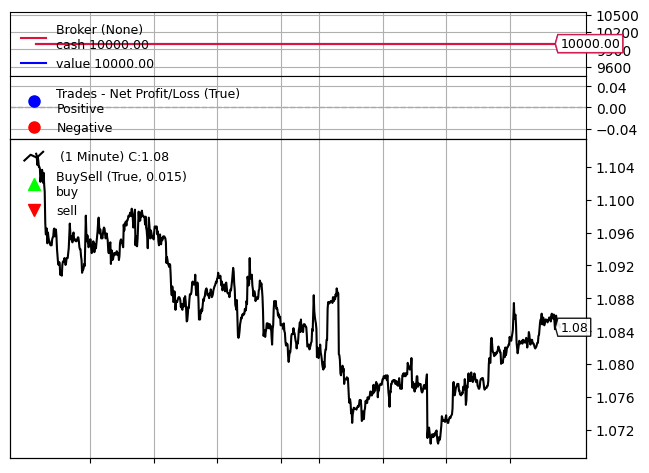

[[<Figure size 640x480 with 4 Axes>]]

In [112]:
cerebro.plot(iplot=False)

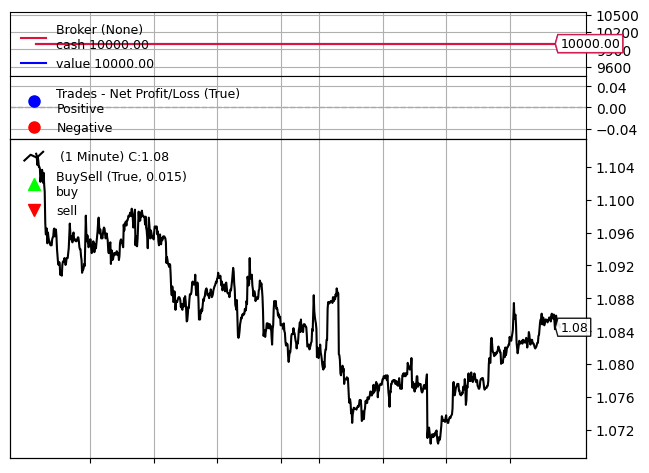

In [96]:
# old saved result
from IPython.display import Image
Image(filename=r"Documents\Backtrader1.PNG")